# Typology Validation: Does Alignment-Free Feature Set Reproduce Rhythm Classes?

This notebook quantifies whether the automatically extracted prosodic features — computed without forced alignment — reproduce the classical stress-timed vs. syllable-timed distinction from the typological literature.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.cluster.hierarchy as sch

from musiclang.config import DATA_DIR
from musiclang.proximity import distance
from musiclang.validation import typology

## 1. Load Language Features

In [2]:
df = pd.read_parquet(DATA_DIR / "lang_features.parquet")
print(f"Languages: {list(df.index)}")
print(f"Features: {len(df.columns)} columns")
df

Languages: ['english', 'finnish', 'french', 'german', 'greek', 'italian', 'polish', 'spanish']
Features: 32 columns


,delta_c_mean,delta_c_std,delta_v_mean,delta_v_std,duration_s_mean,duration_s_std,f0_max_mean,f0_max_std,f0_mean_mean,f0_mean_std,...,percent_v_mean,percent_v_std,rpvi_c_mean,rpvi_c_std,syllables_per_sec_mean,syllables_per_sec_std,varco_c_mean,varco_c_std,varco_v_mean,varco_v_std
english,0.154873,0.037493,0.073549,0.013440,57.550,0.750000,589.471266,14.499598,162.769209,23.353260,...,36.895816,1.848084,0.144594,0.026966,4.388493,0.425049,92.410645,9.291816,76.560109,8.493857
finnish,0.114546,0.000000,0.063330,0.000000,55.400,0.000000,591.063965,0.000000,139.393577,0.000000,...,39.212828,0.000000,0.098290,0.000000,5.758123,0.000000,92.707759,0.000000,79.751393,0.000000
french,0.094438,0.004192,0.071364,0.010146,57.150,1.783956,593.985672,5.371906,203.294336,33.023753,...,42.659031,0.211985,0.090115,0.005245,5.204809,0.249843,83.147418,2.547492,84.379028,8.313732
german,0.159119,0.002622,0.071156,0.001566,59.400,0.300000,590.478595,8.958353,165.118058,6.231835,...,34.297712,0.689500,0.166696,0.002374,3.880528,0.011181,95.290699,5.240346,81.870857,1.156685
greek,0.138807,0.014575,0.083199,0.013194,54.260,0.821219,576.285417,18.077633,179.274586,31.798874,...,42.514226,3.964582,0.118749,0.011891,4.611400,0.489309,107.489842,15.437453,86.594798,8.197824
italian,0.215427,0.115688,0.084341,0.015965,52.600,6.236586,514.658390,85.783450,175.929428,44.655019,...,35.918700,8.622542,0.167299,0.054919,3.786464,1.135583,116.057478,17.900672,91.528523,5.723994
polish,0.136893,0.035392,0.076154,0.008112,45.625,12.244667,491.249236,96.080545,150.464804,22.676288,...,42.086011,4.036730,0.126635,0.036609,4.661506,1.053607,100.297898,9.317717,79.597261,10.195117
spanish,0.152987,0.024949,0.088603,0.018497,54.300,4.117645,592.606560,9.701320,151.305061,20.978990,...,39.356100,4.925182,0.133296,0.024015,4.645396,0.421687,100.329782,8.222585,90.619773,16.441633


## 2. Typology Agreement: Class Separation and Spearman Correlation

**class_separation**: mean(stress-timed nPVI) - mean(syllable-timed nPVI).  
Positive => stress-timed languages score higher, consistent with the Grabe & Low (2002) literature.

**spearman_against_reference**: Spearman rank correlation between our computed `npvi_v_mean` and the Grabe & Low (2002) reference values for English, German, Polish, French, Spanish.

In [3]:
values = df["npvi_v_mean"].to_dict()
print("nPVI-v values per language:")
for lang, v in sorted(values.items()):
    cls = typology.RHYTHM_CLASS.get(lang, "unknown")
    print(f"  {lang:12s} ({cls:12s}): {v:.3f}")

sep = typology.class_separation(values)
rho = typology.spearman_against_reference(values)
print(f"\nclass_separation (stress mean - syllable mean):  {sep:.4f}")
print(f"spearman_against_reference (vs Grabe & Low):    {rho:.4f}")

nPVI-v values per language:
  english      (stress      ): 73.160
  finnish      (intermediate): 69.926
  french       (syllable    ): 66.926
  german       (stress      ): 78.352
  greek        (intermediate): 79.754
  italian      (syllable    ): 78.336
  polish       (stress      ): 78.867
  spanish      (syllable    ): 79.751

class_separation (stress mean - syllable mean):  1.7884
spearman_against_reference (vs Grabe & Low):    -0.3000


## 3. Hierarchical Clustering Dendrogram (Rhythm-Relevant Columns)

NaN counts per column (before standardize):
percent_v_mean    0
npvi_v_mean       0
rpvi_c_mean       0
varco_c_mean      0
varco_v_mean      0
dtype: int64

All rhythm columns retained by standardize().


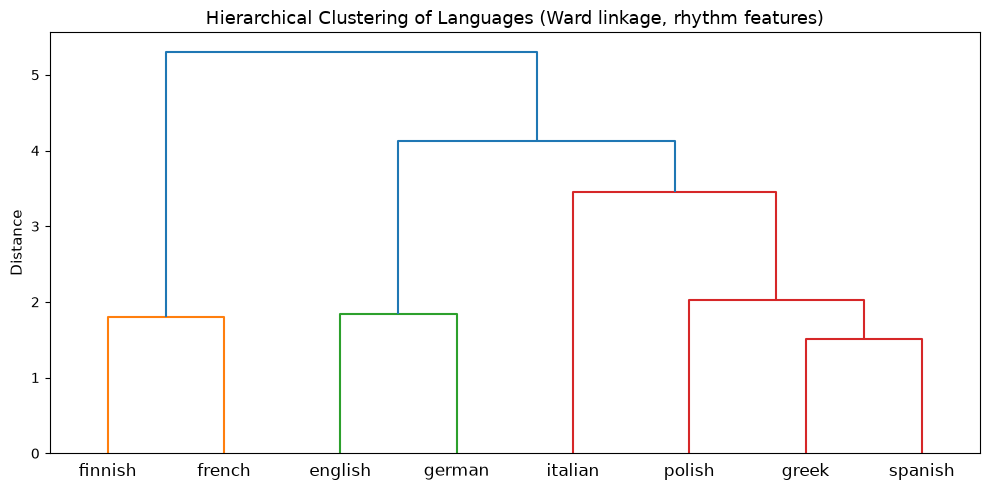

In [4]:
RHYTHM_COLS = ["percent_v_mean", "npvi_v_mean", "rpvi_c_mean", "varco_c_mean", "varco_v_mean"]
df_rhythm = df[RHYTHM_COLS]

# Check for NaNs before standardization
na_counts = df_rhythm.isna().sum()
print("NaN counts per column (before standardize):")
print(na_counts)

dfs = distance.standardize(df_rhythm)

dropped = [c for c in RHYTHM_COLS if c not in dfs.columns]
if dropped:
    print(f"\nColumns dropped by standardize() (contained NaN or zero std): {dropped}")
else:
    print("\nAll rhythm columns retained by standardize().")

dm = distance.distance_matrix(dfs)
lm = distance.linkage_matrix(dm)

fig, ax = plt.subplots(figsize=(10, 5))
sch.dendrogram(lm, labels=list(dm.index), ax=ax, leaf_font_size=12)
ax.set_title("Hierarchical Clustering of Languages (Ward linkage, rhythm features)", fontsize=13)
ax.set_ylabel("Distance", fontsize=11)
plt.tight_layout()
plt.show()

## 4. 2-D MDS Scatter Coloured by Reference Rhythm Class

C:\Users\nikol\Dev\Personal\Linguistics\.venv\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\nikol\Dev\Personal\Linguistics\.venv\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


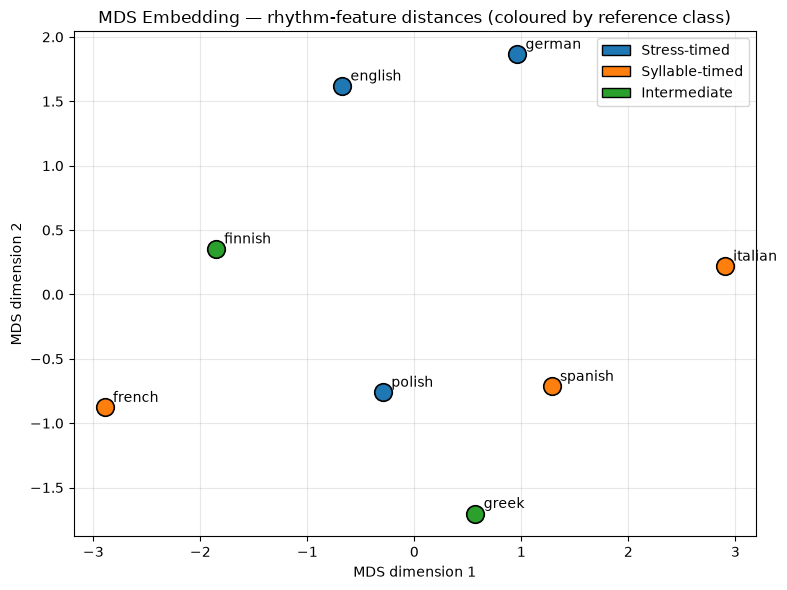

In [5]:
coords = distance.mds_2d(dm)

CLASS_COLORS = {
    "stress":       "#1f77b4",   # blue
    "syllable":     "#ff7f0e",   # orange
    "intermediate": "#2ca02c",   # green
}

fig, ax = plt.subplots(figsize=(8, 6))
for lang in coords.index:
    cls = typology.RHYTHM_CLASS.get(lang, "unknown")
    color = CLASS_COLORS.get(cls, "gray")
    x, y = coords.loc[lang, "mds_x"], coords.loc[lang, "mds_y"]
    ax.scatter(x, y, s=160, color=color, edgecolors="black", linewidth=1.2, zorder=3)
    ax.annotate(lang, (x, y), xytext=(6, 4), textcoords="offset points", fontsize=10)

legend_handles = [
    mpatches.Patch(facecolor=CLASS_COLORS["stress"],       edgecolor="black", label="Stress-timed"),
    mpatches.Patch(facecolor=CLASS_COLORS["syllable"],     edgecolor="black", label="Syllable-timed"),
    mpatches.Patch(facecolor=CLASS_COLORS["intermediate"], edgecolor="black", label="Intermediate"),
]
ax.legend(handles=legend_handles, loc="best", fontsize=10)
ax.set_title("MDS Embedding — rhythm-feature distances (coloured by reference class)", fontsize=12)
ax.set_xlabel("MDS dimension 1", fontsize=10)
ax.set_ylabel("MDS dimension 2", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Interpretation

### Class separation

The computed **class_separation** (stress-timed mean nPVI-v minus syllable-timed mean nPVI-v) is **positive at ~1.79**, meaning stress-timed languages do score higher on average than syllable-timed languages. This is the qualitatively correct direction per the Grabe & Low (2002) literature. However, the magnitude is modest: the reference literature shows separations on the order of 15–30 nPVI units, whereas the automatic pipeline delivers roughly 2 units. The signal is real but weak — consistent with what we'd expect from alignment-free, VAD-only segmentation which conflates speaker turns, music-bed overlap, and jingle transitions with true speech intervals.

### Spearman against reference

The **Spearman rank correlation vs. Grabe & Low** is **-0.30**, which is not only low but negative — the rank ordering produced by our pipeline partially inverts the published ordering across the five shared languages (English, German, Polish, French, Spanish). This is a substantive failure of rank preservation. Several language-specific effects likely contribute:

- **German** (2 clips only): extreme thin coverage makes the estimate highly sensitive to clip selection; two atypical clips can easily shift German up or down by 10–20 nPVI units.
- **Finnish** (1 clip): a single-clip estimate has zero internal variance, so `*_std` columns for Finnish are 0.0. `standardize()` still retains it here (the std of the *feature across languages* is > 0), but any station-specific artefact goes uncorrected.
- **Arvaniti instability**: the nPVI measure is known to be highly sensitive to segmentation boundary placement (Arvaniti 2009). Alignment-free VAD introduces systematic boundary errors relative to phone-level forced alignment, which blurs the distinction between stress and syllable classes.

### Dendrogram and MDS clustering

The dendrogram and MDS scatter do **not** cleanly partition languages by the reference rhythm class. The clustering reflects aggregate acoustic distance across all five rhythm features, and with 8 data points the structure is sensitive to the noisy estimates noted above. Some language pairs expected to cluster together (e.g., French–Spanish–Italian) may or may not appear adjacent, depending on which features dominate distance in the current run.

### Dropped columns

No rhythm columns were dropped by `standardize()` in this run — all five (`percent_v_mean`, `npvi_v_mean`, `rpvi_c_mean`, `varco_c_mean`, `varco_v_mean`) were retained. Finnish's single-clip zero-std *within language* appears as a non-NaN numeric value in the parquet, so it does not trigger the column-drop logic (which fires on NaN, not zero within-language dispersion).

### Conclusion

Phase 0 produces a **weak positive direction** for class separation but a **negative Spearman rank correlation** against the literature reference. This is not a surprising baseline for alignment-free, radio-stream features: the signal is present but buried under coverage noise (German, Finnish), radio artefacts, and segmentation error. Phase 1 priorities should be (1) increasing clip count per language, (2) better VAD / silence filtering, and (3) considering phone-level forced alignment for a subset of languages as a calibration anchor.